In [127]:
import pandas as pd
import numpy as np
import sklearn
import math
import matplotlib.pyplot as plt

## Q1. Consider the hepatitis/ pima-indians-diabetes csv file, perform the following date pre-processing.
## 1. Load data in Pandas.

In [128]:
df=pd.read_csv('Week 3 hepatitis.csv')
df.head()

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,male,False,False,False,False,False,False,False,False,False,False,False,1.0,85.0,18.0,4.0,NaN,False,live
1,50,female,False,False,True,False,False,False,False,False,False,False,False,0.9,135.0,42.0,3.5,NaN,False,live
2,78,female,True,False,True,False,False,True,False,False,False,False,False,0.7,96.0,32.0,4.0,NaN,False,live
3,31,female,NaN,True,False,False,False,True,False,False,False,False,False,0.7,46.0,52.0,4.0,80.0,False,live
4,34,female,True,False,False,False,False,True,False,False,False,False,False,1.0,NaN,200.0,4.0,NaN,False,live


## 2. Drop columns that aren’t useful.

In [129]:
df=df.drop(columns=['age','sex',], errors="ignore")

## 3. Drop rows with missing values

In [130]:
df.dropna().head()

,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
5,True,False,False,False,False,True,False,False,False,False,False,0.9,95.0,28.0,4.0,75.0,False,live
10,False,True,False,False,False,False,True,False,False,False,False,1.3,78.0,30.0,4.4,85.0,False,live
11,True,True,True,False,False,True,True,False,True,False,False,1.0,59.0,249.0,3.7,54.0,False,live
12,True,True,True,False,False,True,True,False,False,False,False,0.9,81.0,60.0,3.9,52.0,False,live
13,True,False,True,False,False,True,True,False,False,False,False,2.2,57.0,144.0,4.9,78.0,False,live


## 4. Create dummy variables.

In [131]:
df["antivirals"] = df["antivirals"].astype(int)
df["histology"] = df["histology"].astype(int)
df=pd.get_dummies(df, drop_first=True)
df.head()

,antivirals,bilirubin,alk_phosphate,sgot,albumin,protime,histology,steroid_True,fatigue_True,malaise_True,anorexia_True,liver_big_True,liver_firm_True,spleen_palpable_True,spiders_True,ascites_True,varices_True,class_live
0,0,1.0,85.0,18.0,4.0,NaN,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0.9,135.0,42.0,3.5,NaN,0,0,1,0,0,0,0,0,0,0,0,1
2,0,0.7,96.0,32.0,4.0,NaN,0,1,1,0,0,1,0,0,0,0,0,1
3,1,0.7,46.0,52.0,4.0,80.0,0,0,0,0,0,1,0,0,0,0,0,1
4,0,1.0,NaN,200.0,4.0,NaN,0,1,0,0,0,1,0,0,0,0,0,1


## 5. Take care of missing data.

In [132]:
df=df.fillna(df.mean(numeric_only=True))
df.head()

,antivirals,bilirubin,alk_phosphate,sgot,albumin,protime,histology,steroid_True,fatigue_True,malaise_True,anorexia_True,liver_big_True,liver_firm_True,spleen_palpable_True,spiders_True,ascites_True,varices_True,class_live
0,0,1.0,85.000000,18.0,4.0,61.852273,0,0,0,0,0,0,0,0,0,0,0,1
1,0,0.9,135.000000,42.0,3.5,61.852273,0,0,1,0,0,0,0,0,0,0,0,1
2,0,0.7,96.000000,32.0,4.0,61.852273,0,1,1,0,0,1,0,0,0,0,0,1
3,1,0.7,46.000000,52.0,4.0,80.000000,0,0,0,0,0,1,0,0,0,0,0,1
4,0,1.0,105.325397,200.0,4.0,61.852273,0,1,0,0,0,1,0,0,0,0,0,1


## 6. Convert the data frame to NumPy.

In [133]:
data=df.to_numpy()
data

array([[  0. ,   1. ,  85. , ...,   0. ,   0. ,   1. ],
       [  0. ,   0.9, 135. , ...,   0. ,   0. ,   1. ],
       [  0. ,   0.7,  96. , ...,   0. ,   0. ,   1. ],
       ...,
       [  0. ,   0.8,  75. , ...,   0. ,   0. ,   1. ],
       [  0. ,   1.5,  81. , ...,   0. ,   1. ,   1. ],
       [  0. ,   1.2, 100. , ...,   1. ,   0. ,   0. ]])

## 7. Divide the data set into training data and test data.

In [134]:
np.random.shuffle(data)

X=data[:, :-1]
y=data[:, -1]

split=int(0.8*len(data))

X_train=X[:split]
X_test=X[split:]

y_train=y[:split]
y_test=y[split:]

## Q2. a. Construct a CSV file with the following attributes:
### Study time in hours of ML lab course (x)
### Score out of 10 (y)
### The dataset should contain 10 rows.

In [189]:
d=np.array([[11,5],[5,3],[30,9],[10,4],[40,10],[3,2],[27,8],[22,6],[28,7],[13,4]])
df2=pd.DataFrame(d)
df2.rename(columns={0:'study_time',1:'score'}, inplace=True)
df2.to_csv('lab_course.csv')

## b. Create a regression model and display the following:
### Coefficients: B0 (intercept) and B1 (slope)
### RMSE (Root Mean Square Error)
### Predicted responses

# Method 1: Pedhazur Method (Intuitive)

In [201]:
xmean=df2['study_time'].mean()
ymean=df2['score'].mean()

df2['x-xmean']=df2['study_time']-xmean
df2['y-ymean']=df2['score']-ymean
df2['x-xmean2']=pow(df2['x-xmean'],2)
df2['xy']=df2['x-xmean']*df2['y-ymean']

numerator=df2['xy'].sum()
denominator=df2['x-xmean2'].sum()

b1=round(numerator/denominator, 2)
b0=round(ymean-b1*xmean, 2)
print(b0, b1)

1.83 0.21


In [202]:
df2['predicted']=round(b0+b1*df2['study_time'],1)
df2['predicted-actual2']=pow(df2['predicted']-df2['score'], 2)

rmse=math.sqrt(df2['predicted-actual2'].sum()/10)
print(round(rmse,2))

0.56


In [203]:
df2[['study_time','score','predicted']]

,study_time,score,predicted
0,11,5,4.1
1,5,3,2.9
2,30,9,8.1
3,10,4,3.9
4,40,10,10.2
5,3,2,2.5
6,27,8,7.5
7,22,6,6.4
8,28,7,7.7
9,13,4,4.6


## c. Create a scatter plot of the data points in red color and plot the graph of x vs. predicted y in blue color.

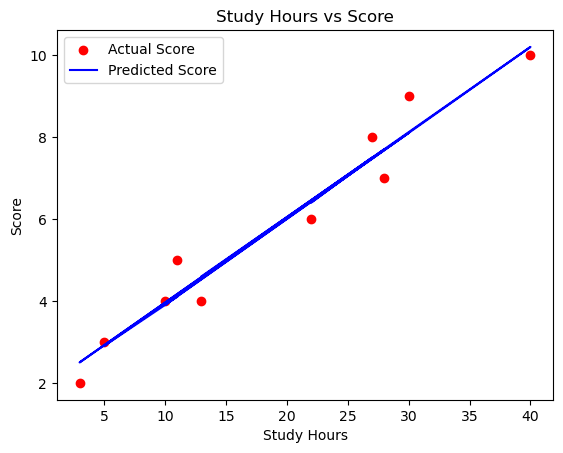

In [204]:
plt.scatter(df2["study_time"], df2["score"], color="red", label="Actual Score")
plt.plot(df2["study_time"], df2["predicted"], color="blue", label="Predicted Score")

plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Study Hours vs Score")
plt.legend()

plt.show()

# Method 2: Calculus Method

In [205]:
df3=pd.DataFrame(d)
df3.rename(columns={0:'study_time',1:'score'}, inplace=True)
df3

,study_time,score
0,11,5
1,5,3
2,30,9
3,10,4
4,40,10
5,3,2
6,27,8
7,22,6
8,28,7
9,13,4


In [206]:
A=np.array([[10, df3['study_time'].sum()],[df3['study_time'].sum(), pow(df3['study_time'],2).sum()]])
B=np.array([[df3['score'].sum()], [(df3['study_time']*df3['score']).sum()]])

coefficients=np.linalg.inv(A)@B
b0=coefficients[0]
b1=coefficients[1]
print(b0, b1)

[1.7955371] [0.21187634]


## e. Compare the coefficients obtained using both methods and compare them with the analytical solution.

## We found that we get the same coefficients using both methods

## f. Test your model to predict the score obtained when the study time of a student is 10 hours.

In [207]:
y=b0+b1*10
print(y)

[3.91430054]


# Additional Qs

## 1) Consider the hepatitis/diabetes CSV file. Create a regression model and display the following:
### a. Coefficients: B0 (intercept) and B1 (slope)
### b. RMSE (Root Mean Square Error)
### c. Predicted responses

In [208]:
df4=pd.read_csv('Week 3 diabetes.csv')
df4.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [209]:
df4=pd.DataFrame({'Glucose':df4['Glucose'], 'Outcome':df4['Outcome']})
df4.head()

,Glucose,Outcome
0,148,1
1,85,0
2,183,1
3,89,0
4,137,1


# Method 1: Pedhazur Method (Intuitive)

In [227]:
xmean=df4['Glucose'].mean()
ymean=df4['Outcome'].mean()

df4['x-xmean']=df4['Glucose']-xmean
df4['y-ymean']=df4['Outcome']-ymean
df4['x-xmean2']=pow(df4['x-xmean'],2)
df4['xy']=df4['x-xmean']*df4['y-ymean']

numerator=df4['xy'].sum()
denominator=df4['x-xmean2'].sum()

b1=numerator/denominator
b0=round(ymean-b1*xmean, 2)
print(b0, b1)

-0.49 0.006960225751927552


In [211]:
df4['Predicted']=round(b0+b1*df4['Glucose'],1)
df4['Predicted-Actual2']=pow(df4['Predicted']-df4['Outcome'], 2)

rmse=math.sqrt(df4['Predicted-Actual2'].sum()/10)
print(round(rmse,2))

3.81


In [214]:
df4[['Glucose','Outcome','Predicted']].head()

,Glucose,Outcome,Predicted
0,148,1,0.6
1,85,0,-0.0
2,183,1,1.0
3,89,0,0.0
4,137,1,0.5


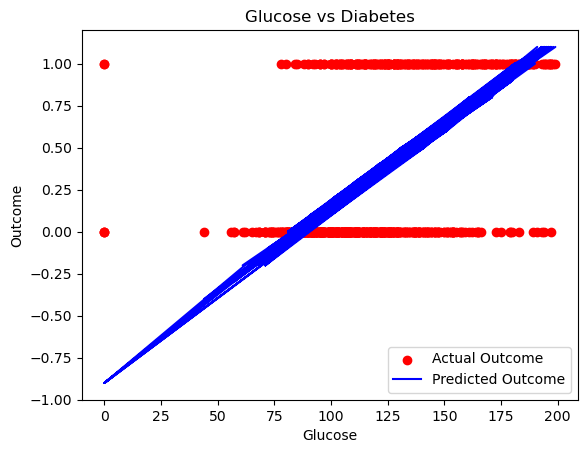

In [215]:
plt.scatter(df4["Glucose"], df4["Outcome"], color="red", label="Actual Outcome")
plt.plot(df4["Glucose"], df4["Predicted"], color="blue", label="Predicted Outcome")

plt.xlabel("Glucose")
plt.ylabel("Outcome")
plt.title("Glucose vs Diabetes")
plt.legend()

plt.show()

# Method 2: Calculus Method

In [219]:
A=np.array([[df4.shape[0], df4['Glucose'].sum()],[df4['Glucose'].sum(), pow(df4['Glucose'],2).sum()]])
B=np.array([[df4['Outcome'].sum()], [(df4['Glucose']*df4['Outcome']).sum()]])

coefficients=np.linalg.inv(A)@B
b0=coefficients[0]
b1=coefficients[1]
print(b0, b1)

[-0.4924949] [0.00696023]


## We found that we get the same coefficients using both methods